In [ ]:
!pip install pillow scikit-image opencv-python matplotlib


Part 1: Using PIL (Pillow)

Type: <class 'PIL.WebPImagePlugin.WebPImageFile'>
Size: (480, 274)
Mode: RGB


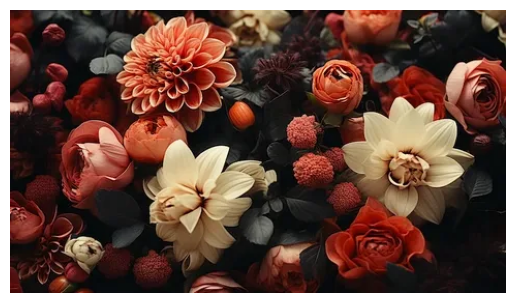

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Open image
img_pil = Image.open("flower.jpg")

# Print info
print("Type:", type(img_pil))
print("Size:", img_pil.size)
print("Mode:", img_pil.mode)

# Display image
plt.imshow(img_pil)
plt.axis("off")
plt.show()

Task 1.1: PIL → NumPy Conversion

In [ ]:
import numpy as np

img_array = np.array(img_pil)

print(f"Array shape: {img_array.shape}")
print(f"Data type: {img_array.dtype}")
print(f"Min pixel value: {img_array.min()}")
print(f"Max pixel value: {img_array.max()}")

Array shape: (274, 480, 3)
Data type: uint8
Min pixel value: 0
Max pixel value: 255


Part 2: Matplotlib Image Reading

Image shape: (274, 480, 3)
Data type: uint8


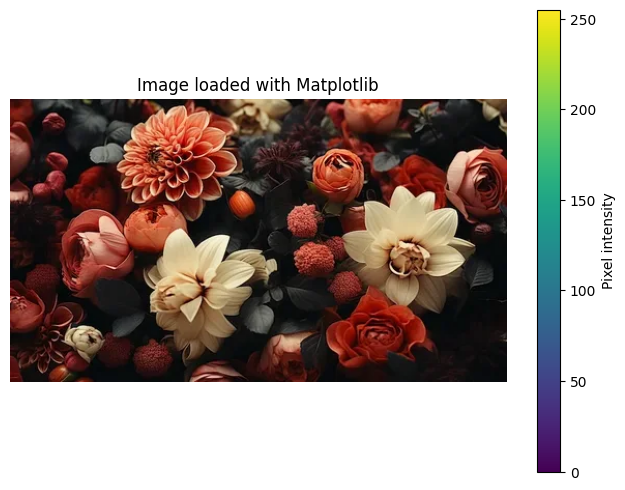

In [ ]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

img_mpl = mpimg.imread("flower.jpg")

print(f"Image shape: {img_mpl.shape}")
print(f"Data type: {img_mpl.dtype}")

plt.figure(figsize=(8, 6))
plt.imshow(img_mpl)
plt.title("Image loaded with Matplotlib")
plt.axis('off')
plt.colorbar(label='Pixel intensity')
plt.show()

Why does Matplotlib treat images as NumPy arrays?

Matplotlib treats images as NumPy arrays because NumPy allows fast numerical operations on pixels, making image visualization and processing easier.

Part 3. Scikit-image

In [ ]:
from skimage import io, img_as_float
import matplotlib.pyplot as plt

Original dtype: uint8
dtype: float64
min pixel value: 0.0
max pixel value: 1.0


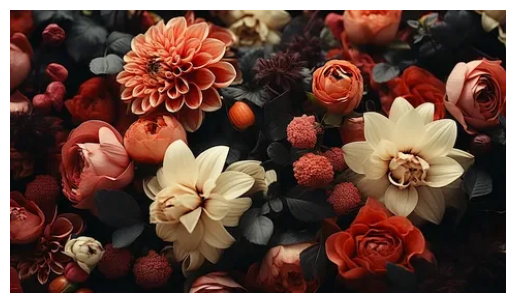

In [ ]:
img_sk = io.imread("flower.jpg")

img_sk_float = img_as_float(img_sk)

print(f"Original dtype: {img_sk.dtype}")
print("dtype:", img_sk_float.dtype)
print("min pixel value:", img_sk_float.min())
print("max pixel value:", img_sk_float.max())

plt.imshow(img_sk_float)
plt.axis("off")
plt.show()

Task 3.1: Data Type Exploration
Q: Why is using astype(float) discouraged compared to img_as_float? Explain briefly.

astype(float) only changes the data type but keeps pixel values in the 0–255 range.
img_as_float converts the image to float and also rescales pixel values to the 0–1 range, which is required for correct image processing in scikit-image.

Part 4: Open cv

In [ ]:
pip install opencv-python

In [ ]:
import cv2

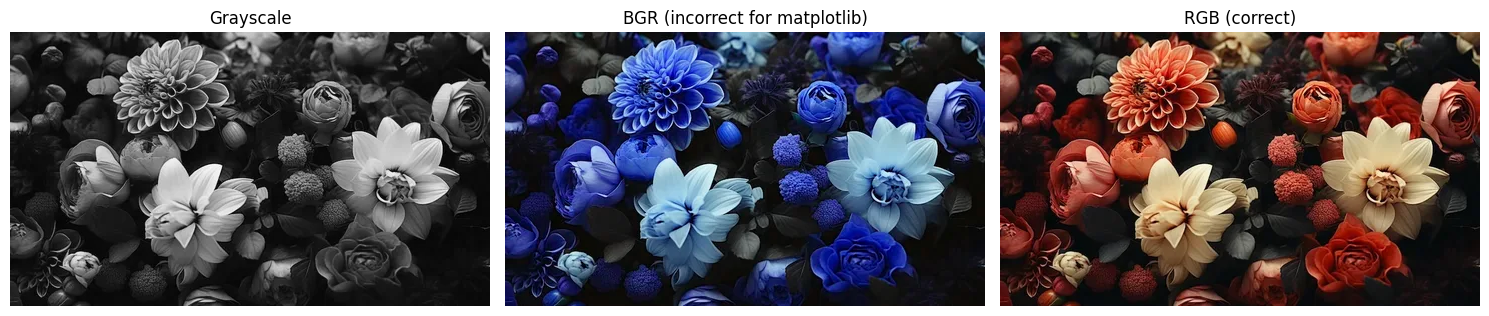

Grayscale shape: (274, 480)
Color image shape: (274, 480, 3)


In [ ]:
img_gray = cv2.imread("flower.jpg", cv2.IMREAD_GRAYSCALE)

img_bgr = cv2.imread("flower.jpg", cv2.IMREAD_COLOR)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Grayscale')
axes[0].axis('off')

axes[1].imshow(img_bgr)
axes[1].set_title('BGR (incorrect for matplotlib)')
axes[1].axis('off')

axes[2].imshow(img_rgb)
axes[2].set_title('RGB (correct)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Grayscale shape: {img_gray.shape}")
print(f"Color image shape: {img_rgb.shape}")

Task 4.1: Image Processing

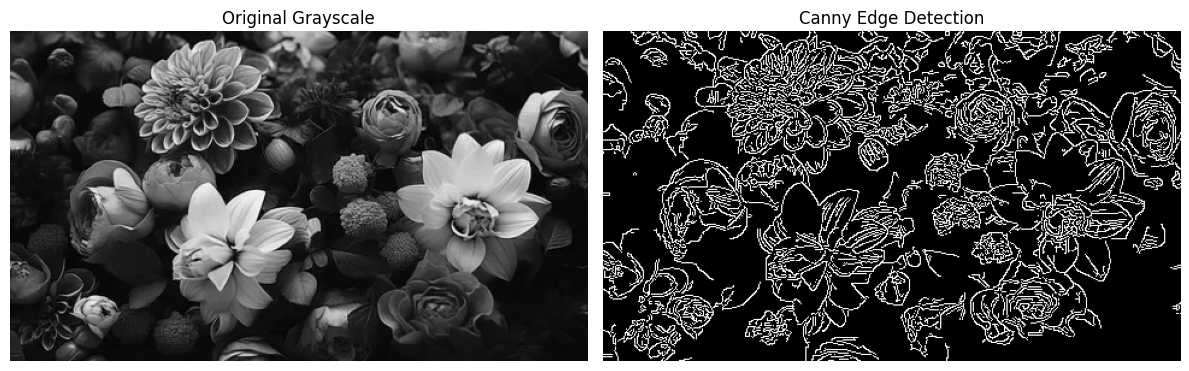

Edge image shape: (274, 480)
Unique values in edge image: [  0 255]


In [ ]:
edges = cv2.Canny(img_gray, threshold1=50, threshold2=150)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edge Detection')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Edge image shape: {edges.shape}")
print(f"Unique values in edge image: {np.unique(edges)}")

Reflection Questions

1.Which library did you find easiest to use? Why?

Matplotlib was the easiest because it reads images directly as NumPy arrays and has simple commands like plt.imshow() for displaying images. It integrates well with NumPy, so viewing and basic processing of images feels very straightforward.

2.Which library would you choose for real-time video processing?

I would choose OpenCV because it is optimized for speed and performance. It supports live camera input, video streams, and many real-time image processing functions such as edge detection, object detection, and filtering, which makes it ideal for real-time applications.

3.What is the main difference between RGB and BGR?

RGB stores colors in the order Red–Green–Blue, which is commonly used by most libraries. OpenCV uses BGR (Blue–Green–Red) by default, so images loaded with OpenCV appear with incorrect colors unless they are converted to RGB.